# 📊 Stance Detection Dataset — HuggingFace Pipeline
**No API keys. No downloads. Just run.**

This notebook loads 3 datasets in order:
1. `tweet_eval stance_climate` → Clean labeled stance data for training
2. `krishnagarg09/SemEval2016Task6` → Multi-topic stance labels (FIXED)
3. `climate_fever` → Climate claims with labels

**Output:** A single merged CSV ready for model training

## 🔧 Step 1: Install Dependencies

In [1]:
!pip install datasets pandas matplotlib seaborn scikit-learn transformers torch

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully')

C:\Users\SUMIT YADAV\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All libraries imported successfully


---
# 📦 DATASET 1: TweetEval Stance (Climate + Feminist)
**Best for:** Training your stance classifier. Clean, labeled, ready to use.

Labels: `0 = Against` | `1 = Neutral` | `2 = Favor`

In [3]:
print('Loading TweetEval - Climate Stance...')
climate_ds = load_dataset('tweet_eval', 'stance_climate')
print('✅ Loaded:', climate_ds)

print('\nLoading TweetEval - Feminist Stance...')
feminist_ds = load_dataset('tweet_eval', 'stance_feminist')
print('✅ Loaded:', feminist_ds)

Loading TweetEval - Climate Stance...


✅ Loaded: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 355
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 169
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 40
    })
})

Loading TweetEval - Feminist Stance...
✅ Loaded: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 597
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 285
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 67
    })
})


In [4]:
label_map_tweeteval = {0: 'against', 1: 'neutral', 2: 'favor'}

def tweeteval_to_df(dataset, topic):
    frames = []
    for split in ['train', 'validation', 'test']:
        if split in dataset:
            df = pd.DataFrame(dataset[split])
            df['split'] = split
            df['topic'] = topic
            df['source'] = 'tweeteval'
            frames.append(df)
    combined = pd.concat(frames, ignore_index=True)
    combined['stance_label'] = combined['label'].map(label_map_tweeteval)
    combined = combined.rename(columns={'text': 'clean_text'})
    return combined[['clean_text', 'stance_label', 'topic', 'source', 'split']]

df_climate_tw  = tweeteval_to_df(climate_ds,  'climate')
df_feminist_tw = tweeteval_to_df(feminist_ds, 'feminist')
df_tweeteval   = pd.concat([df_climate_tw, df_feminist_tw], ignore_index=True)

print(f'✅ TweetEval total rows: {len(df_tweeteval):,}')
print(df_tweeteval['stance_label'].value_counts())
df_tweeteval.head()

✅ TweetEval total rows: 1,513
stance_label
favor      603
neutral    537
against    373
Name: count, dtype: int64


,clean_text,stance_label,topic,source,split
0,Why Is The Pope Upset? via @user #UnzippedTru...,against,climate,tweeteval,train
1,We support Australia's Climate Roundtable whic...,favor,climate,tweeteval,train
2,It's nights like this when I'm not so fond of ...,against,climate,tweeteval,train
3,#Republican party will go down in history book...,against,climate,tweeteval,train
4,RT @user @user We need degrowth - stop destroy...,favor,climate,tweeteval,train


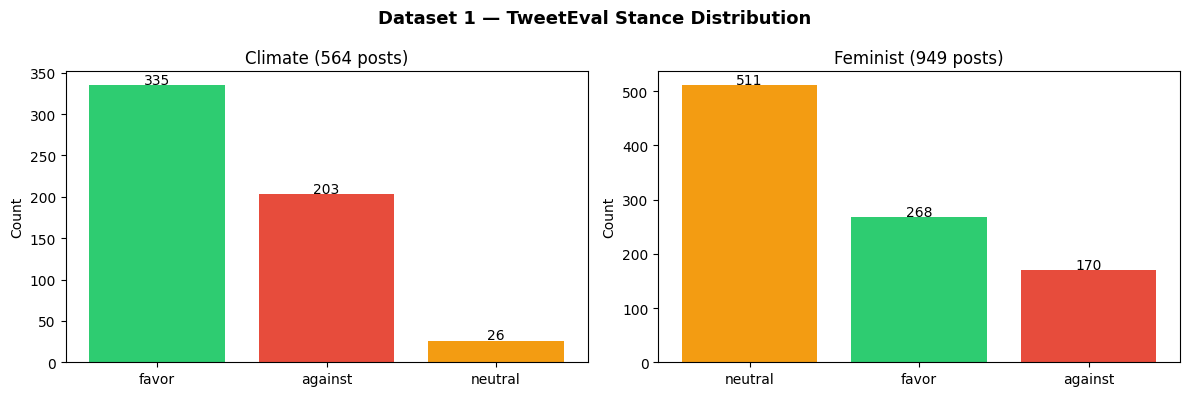

📊 Chart saved: tweeteval_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Dataset 1 — TweetEval Stance Distribution', fontsize=13, fontweight='bold')
colors = {'favor': '#2ecc71', 'neutral': '#f39c12', 'against': '#e74c3c'}

for ax, topic in zip(axes, ['climate', 'feminist']):
    sub = df_tweeteval[df_tweeteval['topic'] == topic]
    counts = sub['stance_label'].value_counts()
    ax.bar(counts.index, counts.values, color=[colors.get(l, 'gray') for l in counts.index])
    ax.set_title(f'{topic.capitalize()} ({len(sub):,} posts)')
    ax.set_ylabel('Count')
    for i, (label, val) in enumerate(counts.items()):
        ax.text(i, val + 2, str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('tweeteval_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved: tweeteval_distribution.png')

---
# 📦 DATASET 2: SemEval 2016 Task 6 (Fixed)
**Best for:** Multi-topic fine-tuning. Covers Climate, Atheism, Feminism, Hillary Clinton, Abortion.

Labels: `FAVOR` | `AGAINST` | `NONE`

In [6]:
print('Loading SemEval 2016 Task 6 (krishnagarg09/SemEval2016Task6)...')
semeval_ds = load_dataset('krishnagarg09/SemEval2016Task6')
print('✅ Loaded:', semeval_ds)
print('\nFeatures:', semeval_ds['train'].features)
print('\nSample row:')
print(semeval_ds['train'][0])

Loading SemEval 2016 Task 6 (krishnagarg09/SemEval2016Task6)...


Generating test split: 100%|██████████| 1080/1080 [00:00<00:00, 180027.36 examples/s]

✅ Loaded: DatasetDict({
    train: Dataset({
        features: ['Tweet', 'Target', 'Stance'],
        num_rows: 2160
    })
    validation: Dataset({
        features: ['Tweet', 'Target', 'Stance'],
        num_rows: 359
    })
    test: Dataset({
        features: ['Tweet', 'Target', 'Stance'],
        num_rows: 1080
    })
})

Features: {'Tweet': Value('string'), 'Target': Value('string'), 'Stance': Value('string')}

Sample row:
{'Tweet': 'dear lord thank u for all of ur blessings forgive my sins lord give me strength and energy for this busy day ahead #blessed #hope #SemST', 'Target': 'Atheism', 'Stance': 'AGAINST'}


In [7]:
def semeval_to_df(dataset):
    frames = []
    for split in dataset.keys():
        df = pd.DataFrame(dataset[split])
        df['split'] = split
        frames.append(df)
    combined = pd.concat(frames, ignore_index=True)
    combined['source'] = 'semeval2016'

    print('Columns found:', combined.columns.tolist())

    # Detect text column
    text_col = next((c for c in ['Tweet', 'text', 'tweet', 'sentence'] if c in combined.columns), combined.columns[0])
    combined = combined.rename(columns={text_col: 'clean_text'})

    # Detect stance column
    stance_col = next((c for c in ['Stance', 'stance', 'label', 'Label'] if c in combined.columns), None)
    if stance_col:
        combined['stance_label'] = combined[stance_col].astype(str).str.lower().replace({'none': 'neutral', 'favor': 'favor', 'against': 'against'})
    else:
        combined['stance_label'] = 'neutral'

    # Detect topic column
    topic_col = next((c for c in ['Target', 'target', 'topic', 'Topic'] if c in combined.columns), None)
    if topic_col:
        combined['topic'] = combined[topic_col].astype(str).str.lower().str.replace(' ', '_')
    else:
        combined['topic'] = 'semeval_topic'

    return combined[['clean_text', 'stance_label', 'topic', 'source', 'split']]

df_semeval = semeval_to_df(semeval_ds)

print(f'\n✅ SemEval total rows: {len(df_semeval):,}')
print('\nTopics:', df_semeval['topic'].unique())
print('\nStance distribution:')
print(df_semeval['stance_label'].value_counts())
df_semeval.head()

Columns found: ['Tweet', 'Target', 'Stance', 'split', 'source']

✅ SemEval total rows: 3,599

Topics: ['atheism' 'feminist_movement' 'hillary_clinton'
 'legalization_of_abortion']

Stance distribution:
stance_label
against    2084
neutral     793
favor       722
Name: count, dtype: int64


,clean_text,stance_label,topic,source,split
0,dear lord thank u for all of ur blessings forg...,against,atheism,semeval2016,train
1,"Blessed are the peacemakers, for they shall be...",against,atheism,semeval2016,train
2,I am not conformed to this world. I am transfo...,against,atheism,semeval2016,train
3,Salah should be prayed with #focus and #unders...,against,atheism,semeval2016,train
4,"Papa God, i pray that You shower me with more ...",against,atheism,semeval2016,train


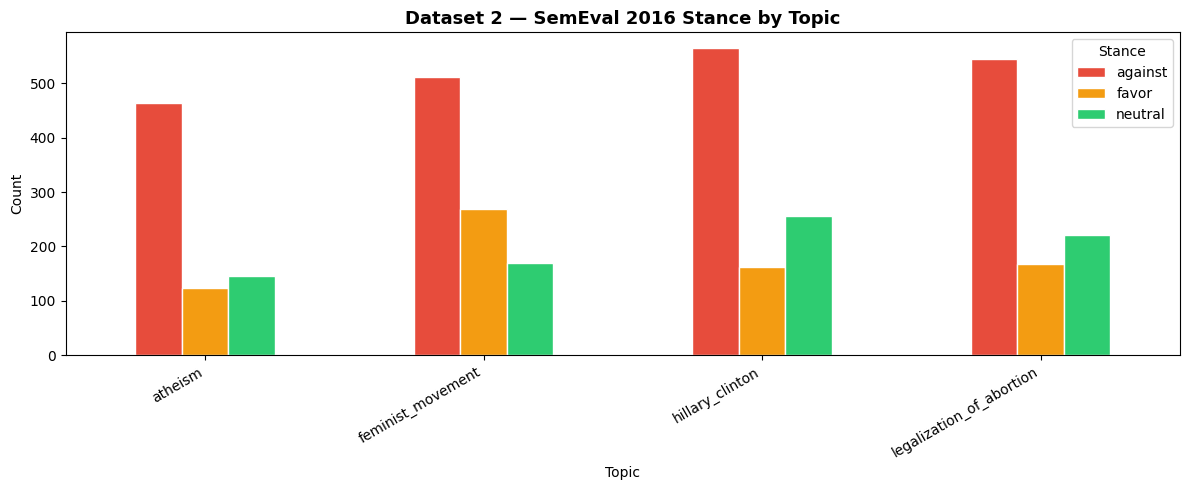

📊 Chart saved: semeval_distribution.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
pivot = df_semeval.groupby(['topic', 'stance_label']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
ax.set_title('Dataset 2 — SemEval 2016 Stance by Topic', fontsize=13, fontweight='bold')
ax.set_xlabel('Topic')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Stance')
plt.tight_layout()
plt.savefig('semeval_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved: semeval_distribution.png')

---
# 📦 DATASET 3: Climate FEVER
**Best for:** Climate-specific claims with evidence labels. Great for inference and domain adaptation.

Labels: `SUPPORTS` | `REFUTES` | `NOT_ENOUGH_INFO` | `DISPUTED`

In [9]:
print('Loading Climate FEVER...')
climate_fever_ds = load_dataset('climate_fever')
print('✅ Loaded:', climate_fever_ds)
print('\nFeatures:', climate_fever_ds['test'].features)
print('\nSample row:')
print(climate_fever_ds['test'][0])

Loading Climate FEVER...


Generating test split: 100%|██████████| 1535/1535 [00:00<00:00, 115633.76 examples/s]

✅ Loaded: DatasetDict({
    test: Dataset({
        features: ['claim_id', 'claim', 'claim_label', 'evidences'],
        num_rows: 1535
    })
})

Features: {'claim_id': Value('string'), 'claim': Value('string'), 'claim_label': ClassLabel(names=['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']), 'evidences': List({'evidence_id': Value('string'), 'evidence_label': ClassLabel(names=['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO']), 'article': Value('string'), 'evidence': Value('string'), 'entropy': Value('float32'), 'votes': List(Value('string'))})}

Sample row:
{'claim_id': '0', 'claim': 'Global warming is driving polar bears toward extinction', 'claim_label': 0, 'evidences': [{'evidence_id': 'Extinction risk from global warming:170', 'evidence_label': 2, 'article': 'Extinction risk from global warming', 'evidence': '"Recent Research Shows Human Activity Driving Earth Towards Global Extinction Event".', 'entropy': 0.6931471824645996, 'votes': ['SUPPORTS', 'NOT_ENOUGH_INFO', None, None, N

In [10]:
def climate_fever_to_df(dataset):
    frames = []
    for split in dataset.keys():
        df = pd.DataFrame(dataset[split])
        df['split'] = split
        frames.append(df)
    combined = pd.concat(frames, ignore_index=True)
    combined['source'] = 'climate_fever'
    combined['topic']  = 'climate'

    print('Columns found:', combined.columns.tolist())

    # Text column
    text_col = next((c for c in ['claim', 'text', 'sentence'] if c in combined.columns), combined.columns[0])
    combined = combined.rename(columns={text_col: 'clean_text'})

    # Label column — map to favor/against/neutral
    label_col = next((c for c in ['claim_label', 'label', 'stance'] if c in combined.columns), None)
    label_map = {
        0: 'favor',    # SUPPORTS
        1: 'against',  # REFUTES
        2: 'neutral',  # NOT_ENOUGH_INFO
        3: 'neutral',  # DISPUTED
        'supports':          'favor',
        'refutes':           'against',
        'not_enough_info':   'neutral',
        'disputed':          'neutral'
    }
    if label_col:
        combined['stance_label'] = combined[label_col].map(label_map).fillna('neutral')
    else:
        combined['stance_label'] = 'neutral'

    return combined[['clean_text', 'stance_label', 'topic', 'source', 'split']]

df_climate_fever = climate_fever_to_df(climate_fever_ds)

print(f'\n✅ Climate FEVER total rows: {len(df_climate_fever):,}')
print('\nStance distribution:')
print(df_climate_fever['stance_label'].value_counts())
df_climate_fever.head()

Columns found: ['claim_id', 'claim', 'claim_label', 'evidences', 'split', 'source', 'topic']

✅ Climate FEVER total rows: 1,535

Stance distribution:
stance_label
favor      654
neutral    628
against    253
Name: count, dtype: int64


,clean_text,stance_label,topic,source,split
0,Global warming is driving polar bears toward e...,favor,climate,climate_fever,test
1,The sun has gone into ‘lockdown’ which could c...,favor,climate,climate_fever,test
2,The polar bear population has been growing.,against,climate,climate_fever,test
3,Ironic' study finds more CO2 has slightly cool...,against,climate,climate_fever,test
4,Human additions of CO2 are in the margin of er...,against,climate,climate_fever,test


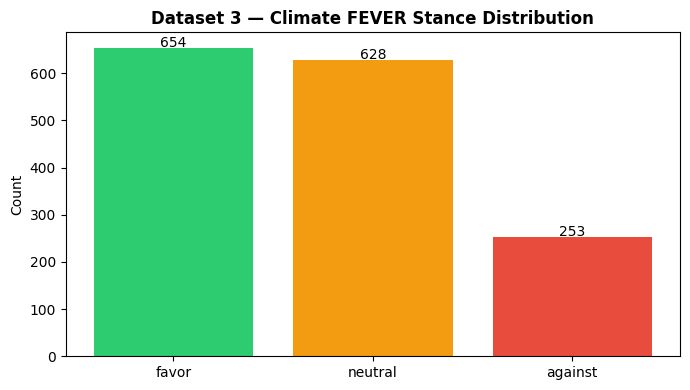

📊 Chart saved: climate_fever_distribution.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df_climate_fever['stance_label'].value_counts()
colors_list = ['#2ecc71' if l == 'favor' else '#e74c3c' if l == 'against' else '#f39c12' for l in counts.index]
ax.bar(counts.index, counts.values, color=colors_list)
ax.set_title('Dataset 3 — Climate FEVER Stance Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
for i, val in enumerate(counts.values):
    ax.text(i, val + 2, str(val), ha='center')
plt.tight_layout()
plt.savefig('climate_fever_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved: climate_fever_distribution.png')

---
# 🔀 Step 4: Merge All 3 Datasets

In [12]:
def normalize_stance(label):
    label = str(label).lower().strip()
    if label in ['favor', 'support', 'supports', '2', 'pro']:        return 'favor'
    if label in ['against', 'oppose', 'refutes', '0', 'con']:        return 'against'
    if label in ['neutral', 'none', '1', 'not_enough_info']:         return 'neutral'
    return 'neutral'

for df in [df_tweeteval, df_semeval, df_climate_fever]:
    df['stance_label'] = df['stance_label'].apply(normalize_stance)

# Merge
df_all = pd.concat([df_tweeteval, df_semeval, df_climate_fever], ignore_index=True)

# Clean
df_all['clean_text'] = df_all['clean_text'].astype(str).str.strip()
df_all = df_all[df_all['clean_text'].str.len() >= 15]
df_all = df_all.drop_duplicates(subset='clean_text').reset_index(drop=True)

print('=' * 50)
print('MERGED DATASET OVERVIEW')
print('=' * 50)
print(f'Total rows:   {len(df_all):,}')
print(f'Topics:       {df_all["topic"].nunique()}')
print(f'Sources:      {list(df_all["source"].unique())}')
print()
print('Stance distribution:')
print(df_all['stance_label'].value_counts())
df_all.head()

MERGED DATASET OVERVIEW
Total rows:   6,091
Topics:       6
Sources:      ['tweeteval', 'semeval2016', 'climate_fever']

Stance distribution:
stance_label
against    2410
neutral    1878
favor      1803
Name: count, dtype: int64


,clean_text,stance_label,topic,source,split
0,Why Is The Pope Upset? via @user #UnzippedTru...,against,climate,tweeteval,train
1,We support Australia's Climate Roundtable whic...,favor,climate,tweeteval,train
2,It's nights like this when I'm not so fond of ...,against,climate,tweeteval,train
3,#Republican party will go down in history book...,against,climate,tweeteval,train
4,RT @user @user We need degrowth - stop destroy...,favor,climate,tweeteval,train


## 📊 Step 5: Full EDA on Merged Dataset

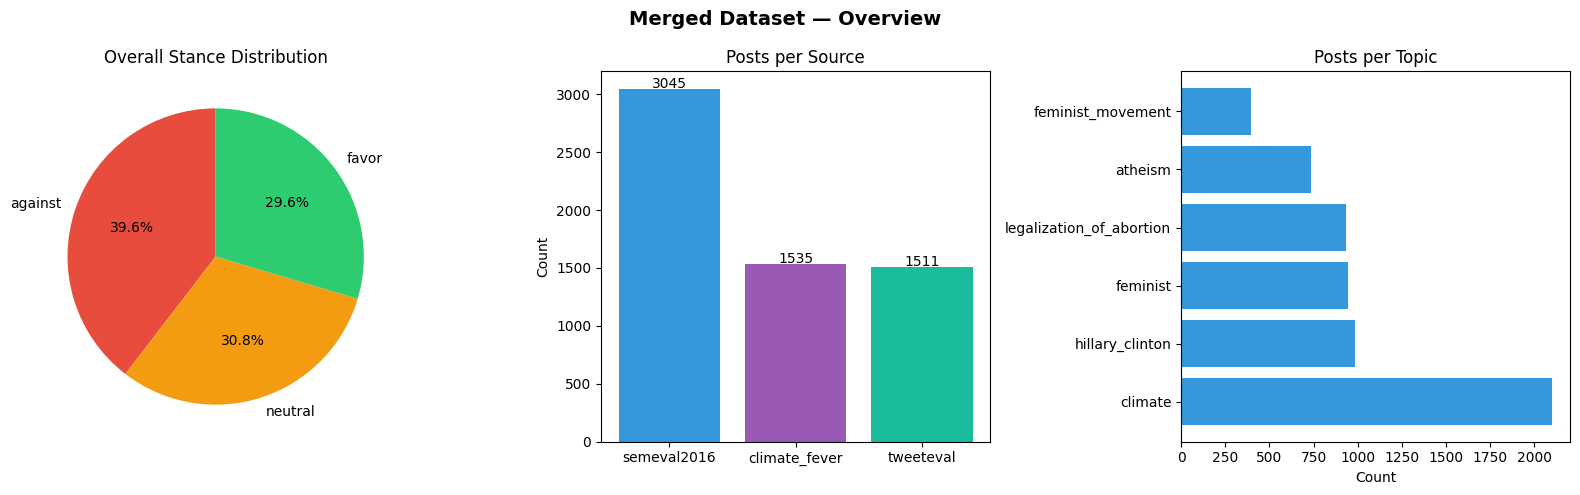

📊 Chart saved: merged_overview.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Merged Dataset — Overview', fontsize=14, fontweight='bold')
colors_stance = ['#e74c3c', '#f39c12', '#2ecc71']

# Chart 1 — Stance distribution pie
stance_counts = df_all['stance_label'].value_counts()
axes[0].pie(stance_counts.values, labels=stance_counts.index,
            colors=colors_stance, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Overall Stance Distribution')

# Chart 2 — Posts per source
source_counts = df_all['source'].value_counts()
axes[1].bar(source_counts.index, source_counts.values,
            color=['#3498db', '#9b59b6', '#1abc9c'])
axes[1].set_title('Posts per Source')
axes[1].set_ylabel('Count')
for i, val in enumerate(source_counts.values):
    axes[1].text(i, val + 5, str(val), ha='center')

# Chart 3 — Posts per topic
topic_counts = df_all['topic'].value_counts().head(8)
axes[2].barh(topic_counts.index, topic_counts.values, color='#3498db')
axes[2].set_title('Posts per Topic')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('merged_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved: merged_overview.png')

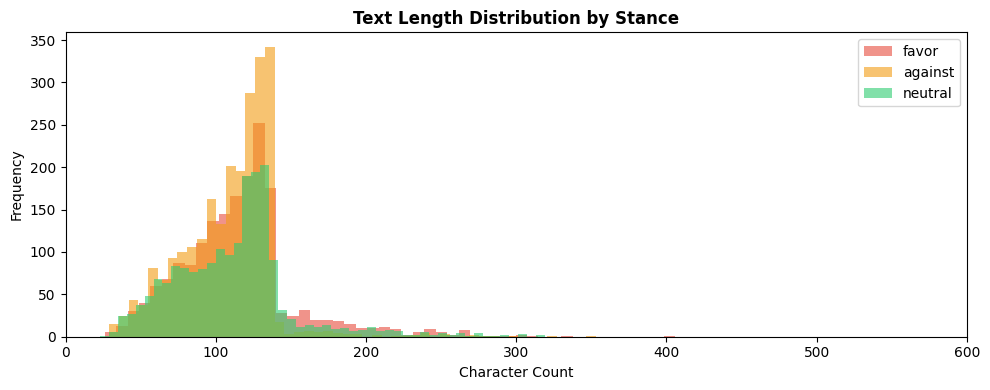

Average text length by stance:
stance_label
against    108.5
favor      115.1
neutral    111.7
Name: text_length, dtype: float64


In [14]:
# Text length distribution
df_all['text_length'] = df_all['clean_text'].str.len()

fig, ax = plt.subplots(figsize=(10, 4))
for stance, color in zip(['favor', 'against', 'neutral'], colors_stance):
    sub = df_all[df_all['stance_label'] == stance]['text_length']
    ax.hist(sub, bins=50, alpha=0.6, label=stance, color=color)

ax.set_title('Text Length Distribution by Stance', fontsize=12, fontweight='bold')
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 600)
ax.legend()
plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average text length by stance:')
print(df_all.groupby('stance_label')['text_length'].mean().round(1))

## 💾 Step 6: Save All Outputs

In [15]:
# Full merged dataset
df_all.to_csv('stance_dataset_merged.csv', index=False)
print(f'✅ stance_dataset_merged.csv        ({len(df_all):,} rows)')

# Labeled only — best for training
df_labeled = df_all[df_all['stance_label'] != 'neutral'][['clean_text', 'stance_label', 'topic', 'source']]
df_labeled.to_csv('stance_dataset_labeled.csv', index=False)
print(f'✅ stance_dataset_labeled.csv       ({len(df_labeled):,} rows)')

# Per source files
for source in df_all['source'].unique():
    sub = df_all[df_all['source'] == source]
    sub.to_csv(f'stance_{source}.csv', index=False)
    print(f'   → stance_{source}.csv  ({len(sub):,} rows)')

print('\n📁 All files saved in your working directory!')

✅ stance_dataset_merged.csv        (6,091 rows)
✅ stance_dataset_labeled.csv       (4,213 rows)
   → stance_tweeteval.csv  (1,511 rows)
   → stance_semeval2016.csv  (3,045 rows)
   → stance_climate_fever.csv  (1,535 rows)

📁 All files saved in your working directory!


## 🔍 Step 7: Sanity Check — Sample Rows

In [16]:
for stance in ['favor', 'against', 'neutral']:
    print(f'=== {stance.upper()} examples ===')
    for text in df_all[df_all['stance_label'] == stance]['clean_text'].sample(3, random_state=42).values:
        print(f'  • {text[:130]}')
    print()

=== FAVOR examples ===
  • @lbush34 @HillaryClinton just defending my girl Hillary! #SemST
  • .@AtheistRepublic Where does our morality come from? < Our innate sense of, and response to, suffering #atheists #HumanRights #Sem
  • Over 31,000 scientists signed the OISM Petition Project

=== AGAINST examples ===
  • A bundle of cells feels more pain than a fully grown women? no. #SemST
  • Woman's Heartbreaking Letter to Father of Baby She Aborted: "I'm So Very Sorry - LifeNews. Please pray for the men hurt by abortio
  • We become what we worship. So be intentional in choosing what you worship for that is what you will become. #worship #SemST

=== NEUTRAL examples ===
  • @KatTimpf @ShannonBream great review. Thanks for your report! Excellent rebuttal of #SemST
  • ‘Getting hung up on the exact nature of the records is interesting, and there’s lots of technical work that can be done there, but
  • For the year-to-date, the Earth is seeing its 5th-warmest start to the year.



---
## ✅ Final Summary

| File | Description |
|---|---|
| `stance_dataset_merged.csv` | All 3 datasets combined |
| `stance_dataset_labeled.csv` | Favor + Against only — use for training |
| `stance_tweeteval.csv` | TweetEval only |
| `stance_semeval2016.csv` | SemEval 2016 only |
| `stance_climate_fever.csv` | Climate FEVER only |

### 🚀 Next Steps
1. Use `stance_dataset_labeled.csv` to **fine-tune RoBERTa**
2. Run inference on full dataset
3. Track stance over time
4. Build Streamlit dashboard